# Figure 3: Chromatin and Gene Expression

**Goal:**

Show the relationship of the chromatin and gene expression with respect to cell phases. What patterns are different per cell phase?

**Procedure:**
1. Partition out the genes by where there maximal expression lies (criteria: expression is 1.5 greater in the phase than any other phase). Quantify this.
2. Then, plot the 90/10 PTR ratio for the chromatin for each of these highly expressed genes
3. Are there any discernible patterns in the chromatin for each cell phase?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [469]:
from src.Figure3_Chrom_Gene_Expression import Figure3_Chrom_GeneExpression

outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'

figures = Figure3_Chrom_GeneExpression(outdir)

In [483]:
figures.load_ptrs()

In [485]:
figures.correct_ptr_imgs()

In [470]:
from src.config import load_configs_by_config_type

config1, config2 = load_configs_by_config_type('shared')
gene_expression = figures.gene_expression_a.gene_expression_f

In [471]:
t_indices = config1.get_Hpositions_for_branch('t')

In [478]:
from src.geneset import get_deconvolved_geneset
figures.genes = get_deconvolved_geneset()
figures.genes['gene_index'] = np.arange(len(figures.genes))

In [479]:
from src.peak_to_trough import compute_quantile_ptr_2d

ret_ptr = compute_quantile_ptr_2d(gene_expression[t_indices], lo=0.1, hi=0.9, 
                                  return_indices=True)
ptr_df = pd.DataFrame(ret_ptr, index=gene_expression.index)
ptr_df.columns = ['ptr', 'lo_val_idx', 'hi_val_idx', 'f_lo', 'f_hi']
ptr_df.lo_val_idx = ptr_df.lo_val_idx.astype(int)
ptr_df.hi_val_idx = ptr_df.hi_val_idx.astype(int)
ptr_df = ptr_df.join(figures.genes[['gene_index']])

In [480]:
def get_partition_labels(n, n_partitions = 5):
    """Get the partition labels for a dataframe of size n"""
    
    step = n / n_partitions
    partition_labels = np.zeros(n)

    for i in range(n_partitions):
        start = int(i*step)
        end = int((i+1)*step) if i < n_partitions-1 else n
        partition_labels[start:end] = i
    
    return partition_labels


In [481]:
from src.global_config import GlobalConstants
from src.timer import Timer

def retrieve_peak_trough_ptr_imgs(current_orfs):
    def retrieve_peak_trough_imgs(orf_name):
        """Retrieve the peak and trough images for an orf"""
        from glob import glob
        f_mat_path = glob(f'{figures.outdir}chromatin/*_f_*{orf_name}*')[0]
        f_mat = np.load(f_mat_path)
        f_img = f_mat.reshape((-1, *GlobalConstants.IMAGE_SHAPE))
        ptr_row = ptr_df.loc[orf_name]
        lo_idx, hi_idx = int(ptr_row.lo_val_idx), int(ptr_row.hi_val_idx)
        lo_img = f_img[lo_idx]
        hi_img = f_img[hi_idx]
        return lo_img, hi_img

    timer = Timer()

    peak_cumulative_image = np.zeros(GlobalConstants.IMAGE_SHAPE)
    trough_cumulative_image = np.zeros(GlobalConstants.IMAGE_SHAPE)
    k = len(current_orfs)
    for i in range(k):
        orf_name = current_orfs[i]
        lo_img, hi_img = retrieve_peak_trough_imgs(orf_name)
        gene = figures.genes.loc[orf_name]

        if gene.strand == '-':
            lo_img = np.flip(lo_img, axis=1)
            hi_img = np.flip(hi_img, axis=1)

        # todo: normalize these images prior to accumulation...
        # don't fully understand the source of variation.
        # Could be a bug in copy number correction/normalisation or 
        # something unaccounted for
        TARGET_COUNT = 1000
        hi_img = hi_img / hi_img.sum() * TARGET_COUNT
        lo_img = lo_img / lo_img.sum() * TARGET_COUNT
            
        peak_cumulative_image += hi_img
        trough_cumulative_image += lo_img

        if i % 200 == 0: 
            timer.print_time(f"{i}/{k}")

    selected_indices = figures.genes.loc[current_orfs].gene_index.values
    ptr_cumulative_image = figures.ptr_imgs_strand_corrected[selected_indices].mean(axis=0)

    return peak_cumulative_image/k, trough_cumulative_image/k, \
        ptr_cumulative_image, (peak_cumulative_image-trough_cumulative_image)/k


In [486]:
n_partitions = 5
ptr_partition_img_sets, ptr_df_partitioned = create_partition_img_sets(ptr_df, sort_key='hi_f', 
    n_partitions=n_partitions, key='partition')

Retrieving images for partition: 0
0/1115 - 00:00:00.174
200/1115 - 00:00:08.872
400/1115 - 00:00:17.673
600/1115 - 00:00:26.298
800/1115 - 00:00:34.891
1000/1115 - 00:00:43.232
Retrieving images for partition: 1
0/1116 - 00:00:00.044
200/1116 - 00:00:08.382
400/1116 - 00:00:16.784
600/1116 - 00:00:25.369
800/1116 - 00:00:34.191
1000/1116 - 00:00:43.735
Retrieving images for partition: 2
0/1115 - 00:00:00.045
200/1115 - 00:00:09.151
400/1115 - 00:00:18.027
600/1115 - 00:00:26.455
800/1115 - 00:00:34.902
1000/1115 - 00:00:43.380
Retrieving images for partition: 3
0/1116 - 00:00:00.050
200/1116 - 00:00:08.594
400/1116 - 00:00:17.270
600/1116 - 00:00:25.997
800/1116 - 00:00:34.934
1000/1116 - 00:00:43.670
Retrieving images for partition: 4
0/1116 - 00:00:00.045
200/1116 - 00:00:08.914
400/1116 - 00:00:17.627
600/1116 - 00:00:26.279
800/1116 - 00:00:34.913
1000/1116 - 00:00:43.788


0

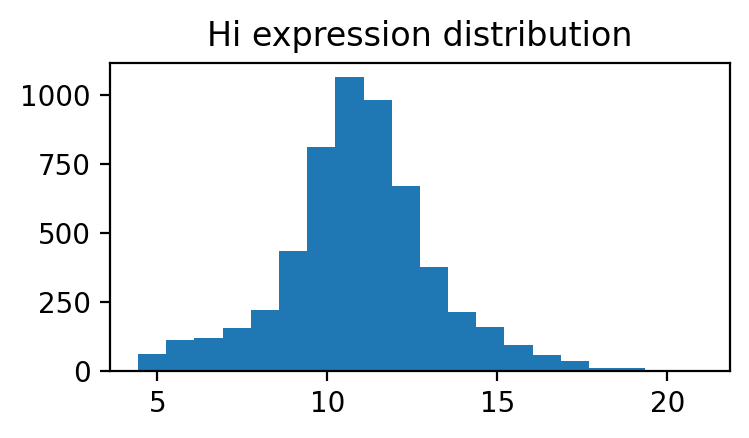

In [487]:
plt.figure(figsize=(4, 2))
plt.hist(ptr_df.f_hi, bins=20)
plt.title("Hi expression distribution")
0

In [531]:
from src.figure_configs import FiguresConfig

def plot_partition_set(partition_img_sets, title):
    plt.figure(figsize=(16, 10))
        
    for i in range(len(partition_img_sets)):
        peak_cumulative_image, trough_cumulative_image, ptr_cumulative_image,\
            difference_cumulative_image = partition_img_sets[i]

        plt.subplot(5, 4, (i*4)+1)
        def plot_img(img):
            plt.imshow(img, aspect='auto', cmap='magma_r', origin='lower')
            plt.xticks([])
            plt.yticks([])
            plt.axvline(img.shape[1]//2, c='black', alpha=0.1, lw=2)
        plot_img(peak_cumulative_image)
        plt.ylabel(f"Quantile {i+1}")
        if i == 0: plt.title("Peak")

        plt.subplot(5, 4, (i*4)+2)
        plot_img(trough_cumulative_image)
        if i == 0: plt.title("Trough")
            
        plt.subplot(5, 4, (i*4)+3)
        plt.imshow(ptr_cumulative_image, aspect='auto',
                  origin='lower', cmap='Spectral_r', vmin=1, vmax=3)
        plt.xticks([])
        plt.yticks([])
        if i == 0: plt.title("PTR")
                
        plt.subplot(5, 4, (i*4)+4)
        plt.imshow(difference_cumulative_image, aspect='auto',
                  origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
        plt.xticks([])
        plt.yticks([])
        plt.axvline(peak_cumulative_image.shape[1]//2, c='black', alpha=0.1, lw=2)
        if i == 0: plt.title("Difference: Peak-Trough")

        plt.suptitle(title, fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
        plt.subplots_adjust(top=0.9, hspace=0.3, wspace=0.2)


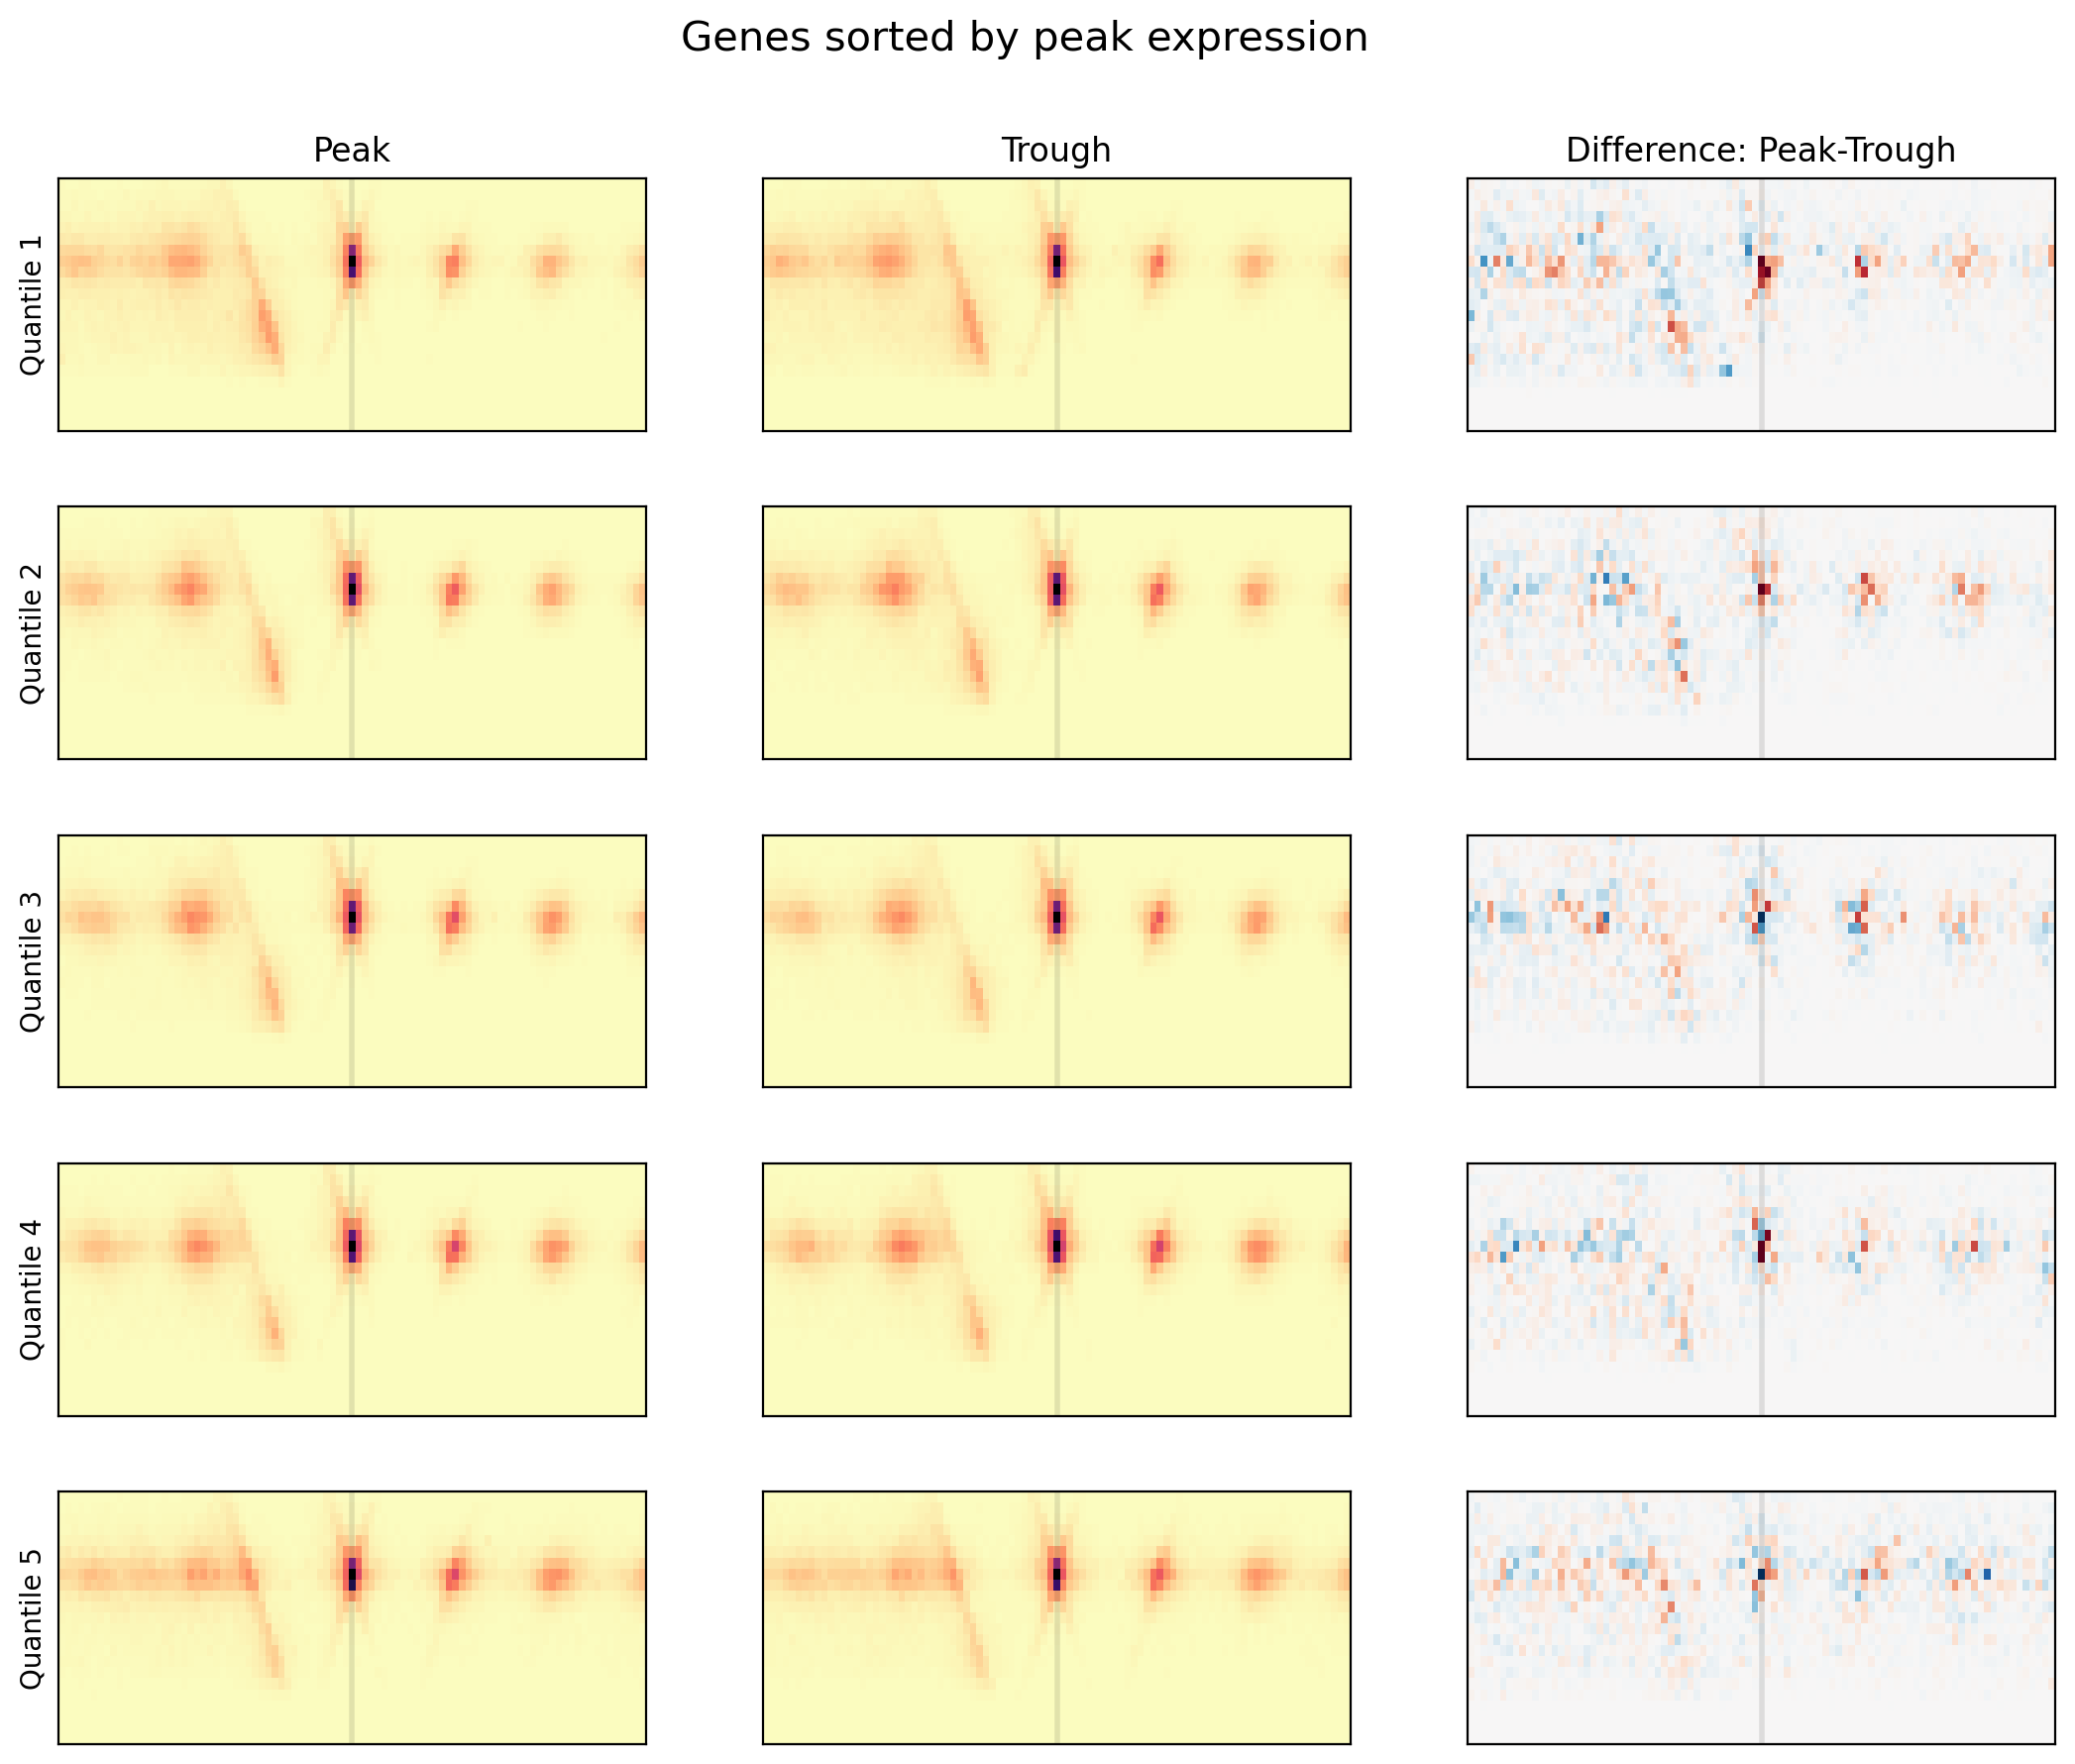

In [489]:
from src.figure_configs import FiguresConfig, save_figure_for_paper

plot_partition_set(partition_img_sets, f"Genes sorted by peak expression")
save_figure_for_paper("output/figures/Expression_Chromatin/Chromatin_PT_by_Expression.png")


In [490]:
# Get the highest transcription quintile, and sort by PTR
hi_tx_sorted_ptr = ptr_partitioned_df[ptr_partitioned_df.partition == 0]\
    .sort_values('ptr', ascending=False)

In [523]:
def create_partition_img_sets(ptr_df, sort_key, n_partitions, key):
    ptr_df_partitioned = ptr_df.sort_values(sort_key, ascending=False).copy()
    ptr_df_partitioned[key] = get_partition_labels(
        len(ptr_df_partitioned), n_partitions).astype(int)

    partitioned_ptrs_img_sets = []
    for partition_num in range(n_partitions):
        partitioned_set_df = ptr_df_partitioned[
            ptr_df_partitioned[key] == partition_num]
        current_orfs = partitioned_set_df.index

        print(f"Retrieving images for partition: {partition_num}")
        peak_cumulative_image, trough_cumulative_image, ptr_cumulative_image, \
            difference_image =  retrieve_peak_trough_ptr_imgs(current_orfs)
        partitioned_ptrs_img_sets.append((peak_cumulative_image, 
            trough_cumulative_image, ptr_cumulative_image, difference_image))
    
    return partitioned_ptrs_img_sets, ptr_df_partitioned


In [502]:
hi_tx_partition_img_sets, _ = create_partition_img_sets(hi_tx_sorted_ptr, sort_key='ptr', 
    n_partitions=4, key='ptr_partition')

Retrieving images for partition: 0
0/278 - 00:00:00.154
200/278 - 00:00:09.149
Retrieving images for partition: 1
0/279 - 00:00:00.045
200/279 - 00:00:08.779
Retrieving images for partition: 2
0/279 - 00:00:00.044
200/279 - 00:00:08.732
Retrieving images for partition: 3
0/279 - 00:00:00.045
200/279 - 00:00:08.730


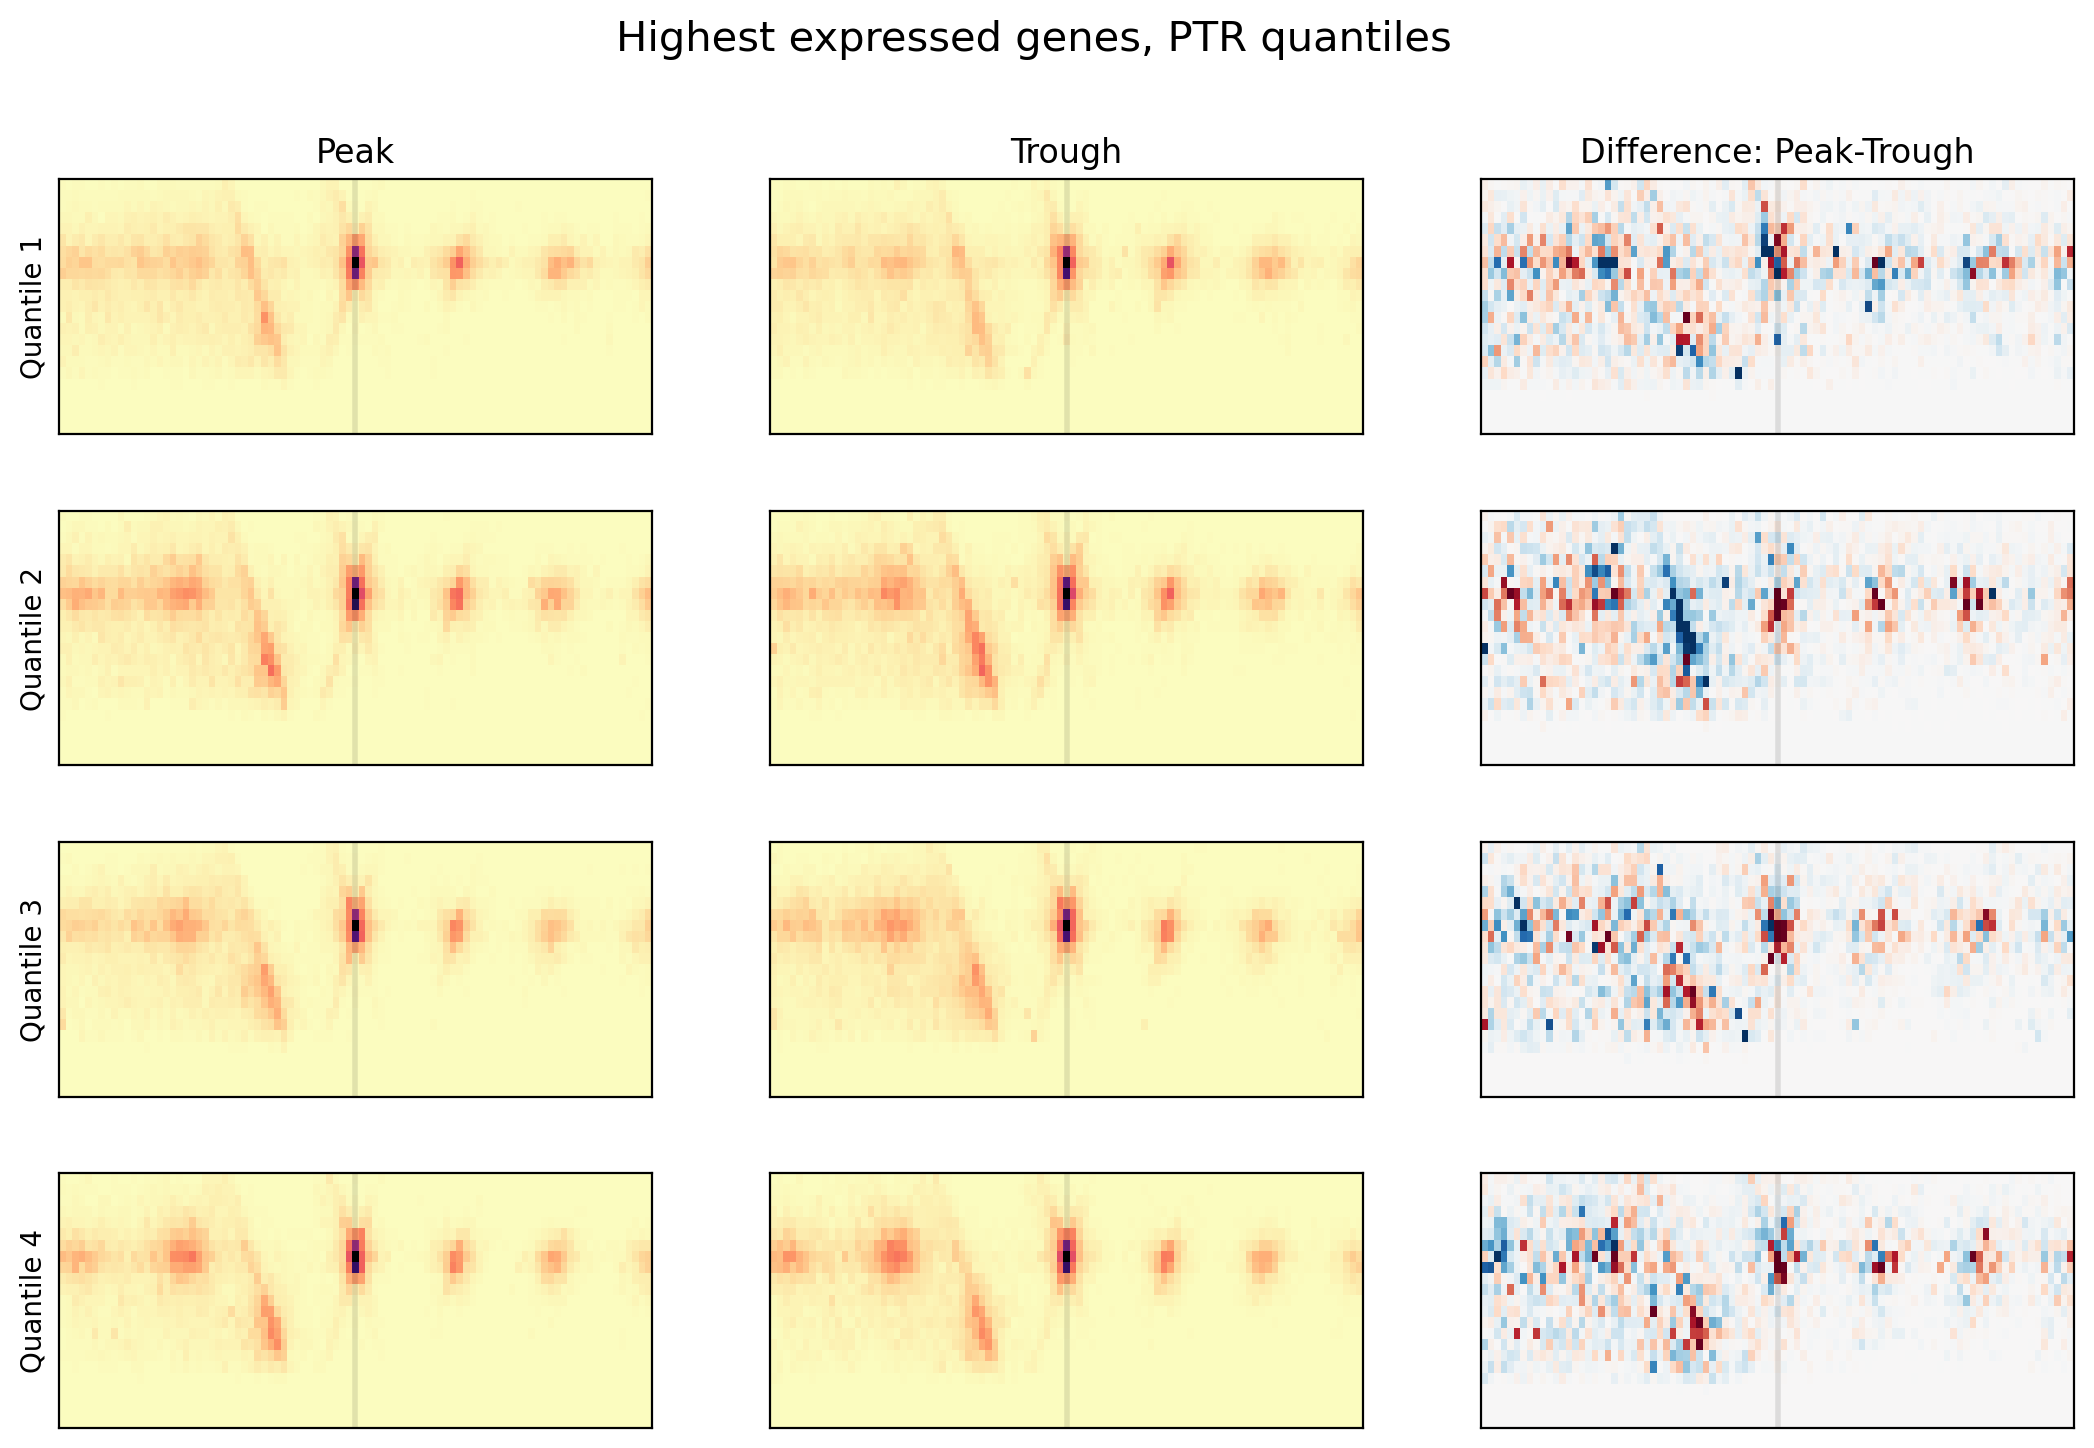

In [493]:
plot_partition_set(hi_tx_partition_img_sets, "Highest expressed genes, PTR quantiles")
save_figure_for_paper("output/figures/Expression_Chromatin/High_Expression_Chromatin_PT_by_Expression.png")

In [518]:
ptr_partition_img_sets, partitioned_ptrs_df = create_partition_img_sets(ptr_df, sort_key='ptr', 
    n_partitions=5, key='ptr_partition')

Retrieving images for partition: 0
0/1115 - 00:00:00.043
200/1115 - 00:00:08.493
400/1115 - 00:00:17.228
600/1115 - 00:00:25.888
800/1115 - 00:00:34.443
1000/1115 - 00:00:42.904
Retrieving images for partition: 1
0/1116 - 00:00:00.043
200/1116 - 00:00:08.694
400/1116 - 00:00:17.348
600/1116 - 00:00:25.918
800/1116 - 00:00:34.420
1000/1116 - 00:00:42.838
Retrieving images for partition: 2
0/1115 - 00:00:00.043
200/1115 - 00:00:08.445
400/1115 - 00:00:16.897
600/1115 - 00:00:25.355
800/1115 - 00:00:33.840
1000/1115 - 00:00:42.541
Retrieving images for partition: 3
0/1116 - 00:00:00.043
200/1116 - 00:00:08.623
400/1116 - 00:00:17.173
600/1116 - 00:00:25.780
800/1116 - 00:00:34.236
1000/1116 - 00:00:42.781
Retrieving images for partition: 4
0/1116 - 00:00:00.042
200/1116 - 00:00:08.584
400/1116 - 00:00:17.059
600/1116 - 00:00:25.508
800/1116 - 00:00:33.995
1000/1116 - 00:00:42.494


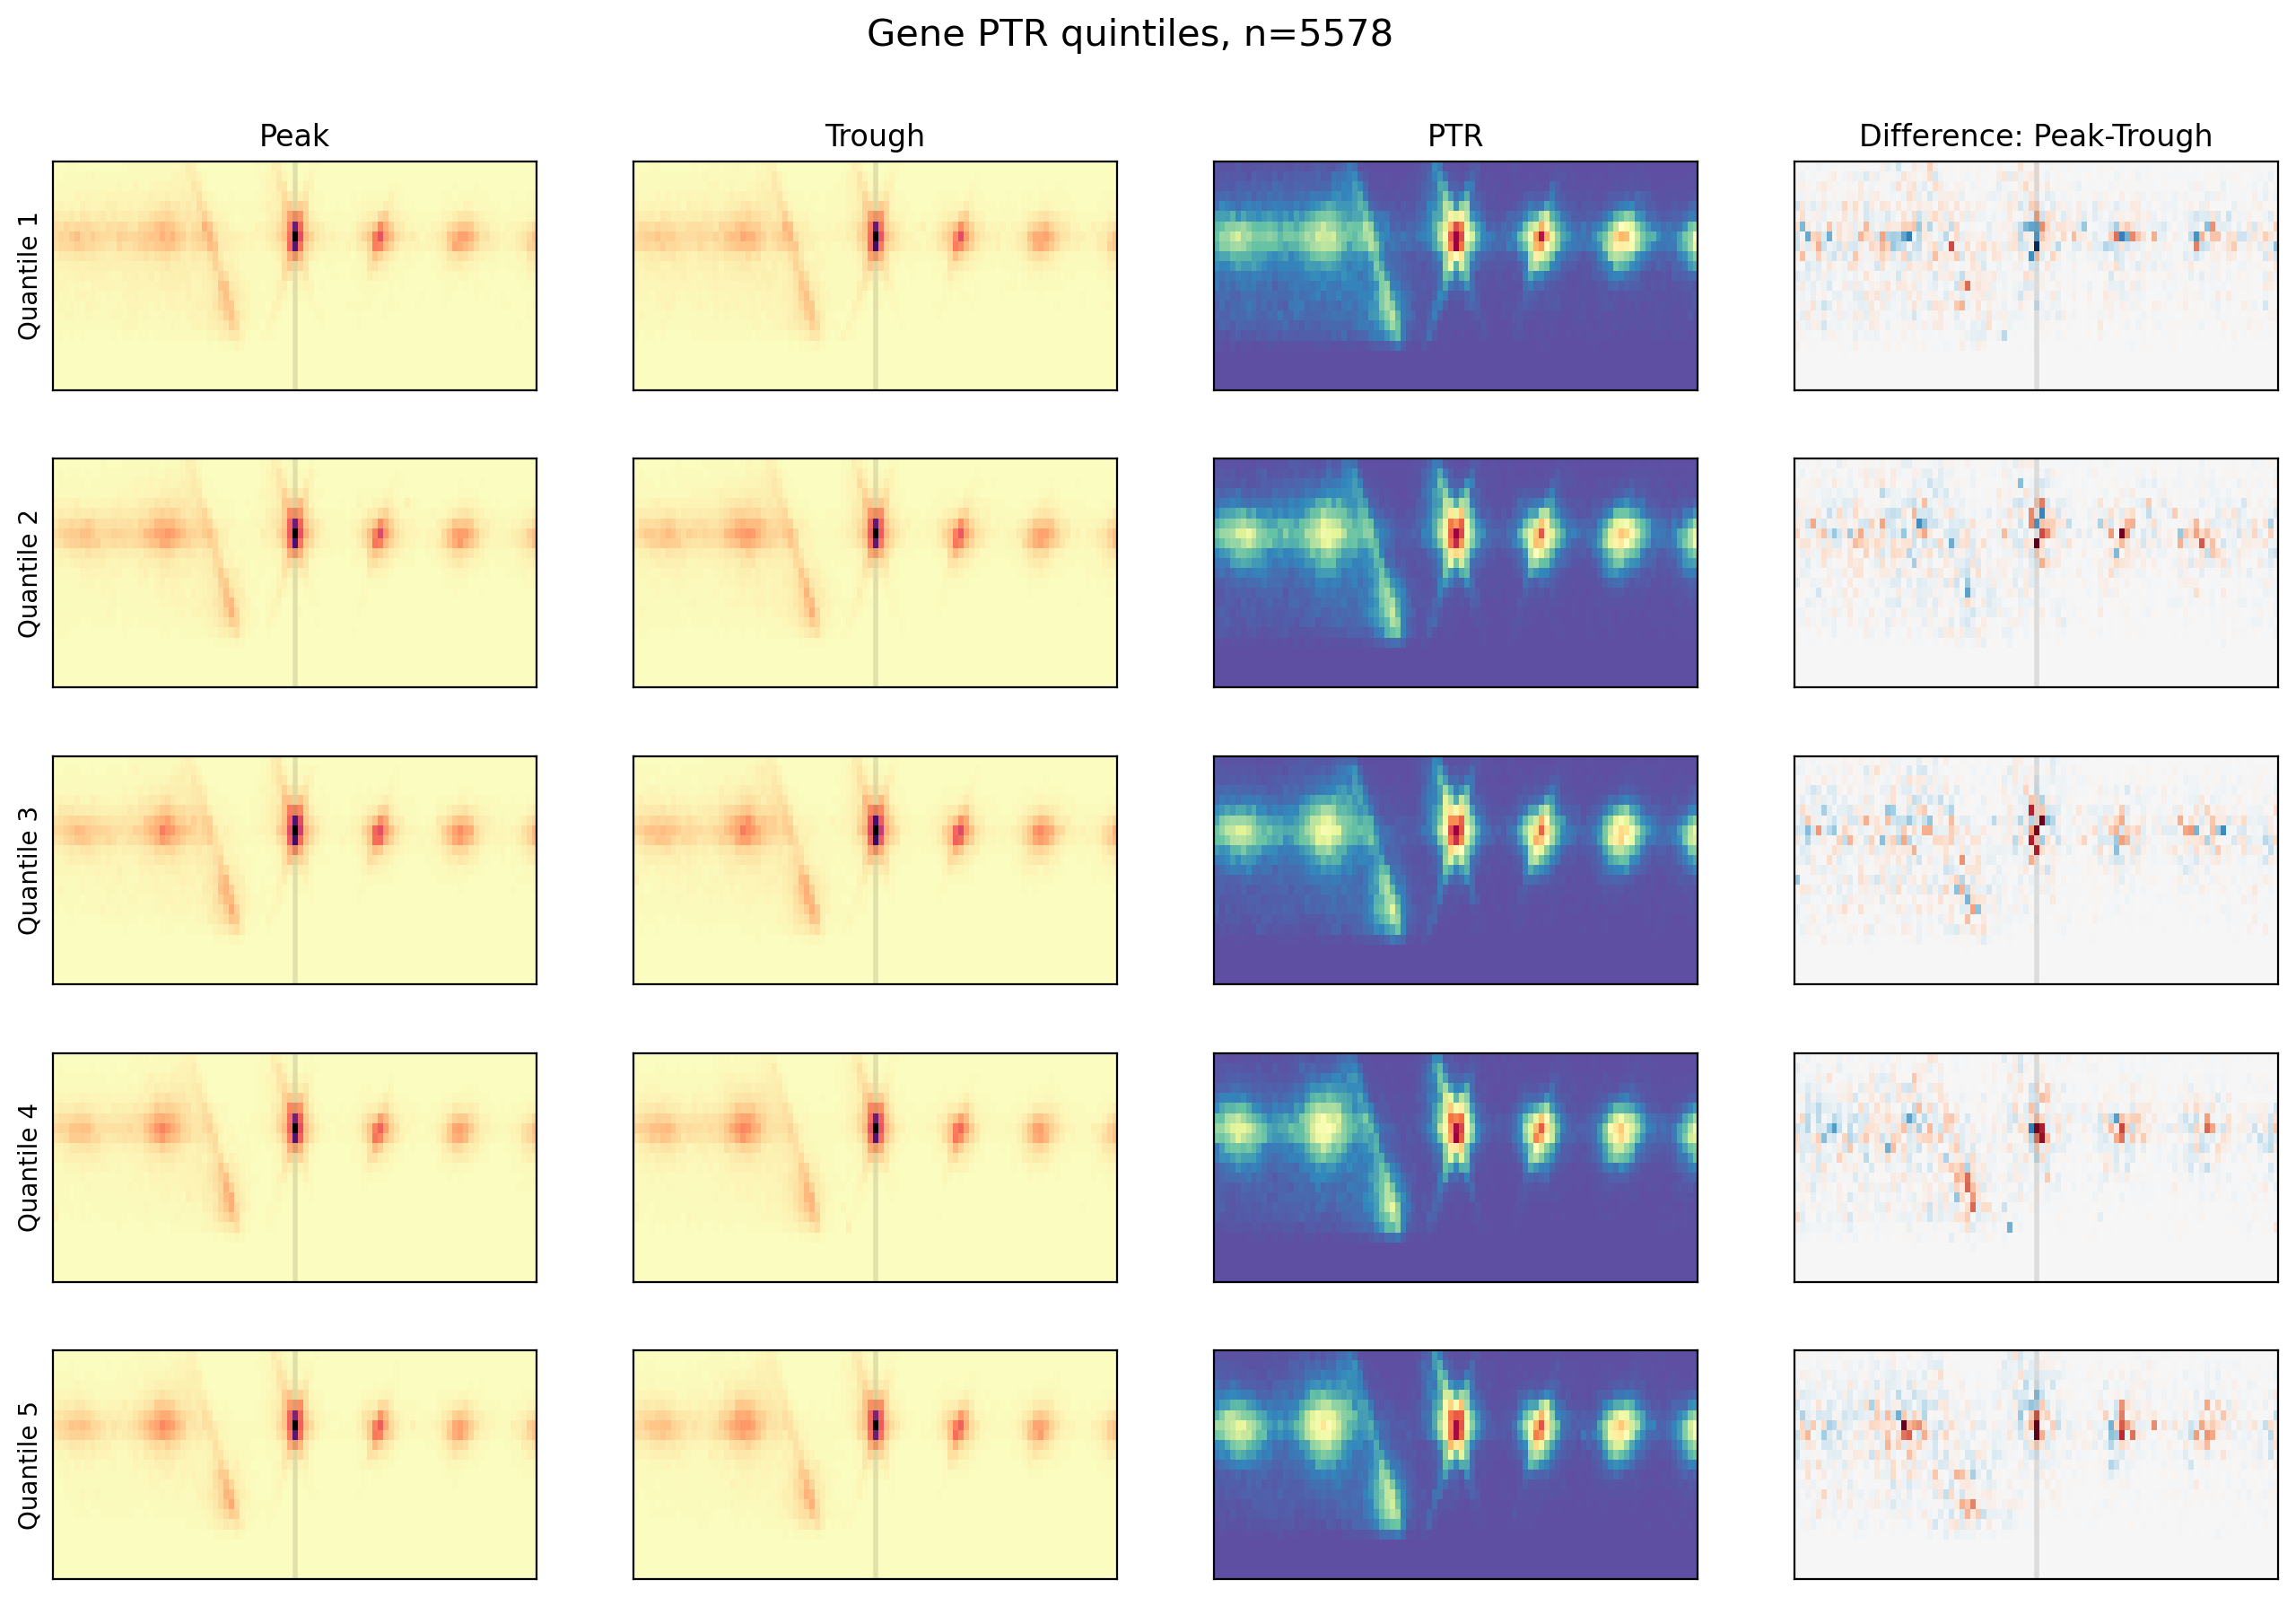

In [535]:
plot_partition_set(ptr_partition_img_sets, f"Gene PTR quintiles, n={len(ptr_df)}")
save_figure_for_paper("output/figures/Expression_Chromatin/Chromatin_sorted_by_PTR.png")

In [526]:
hi_ptrs_df = partitioned_ptrs_df[partitioned_ptrs_df.ptr_partition == 0]

hi_ptrs_partition_img_sets, _ = create_partition_img_sets(hi_ptrs_df, 
    sort_key='f_hi', n_partitions=4, key='hi_ptr_tx_partition')


Retrieving images for partition: 0
0/278 - 00:00:00.044
200/278 - 00:00:08.541
Retrieving images for partition: 1
0/279 - 00:00:00.043
200/279 - 00:00:08.574
Retrieving images for partition: 2
0/279 - 00:00:00.044
200/279 - 00:00:08.678
Retrieving images for partition: 3
0/279 - 00:00:00.043
200/279 - 00:00:08.563


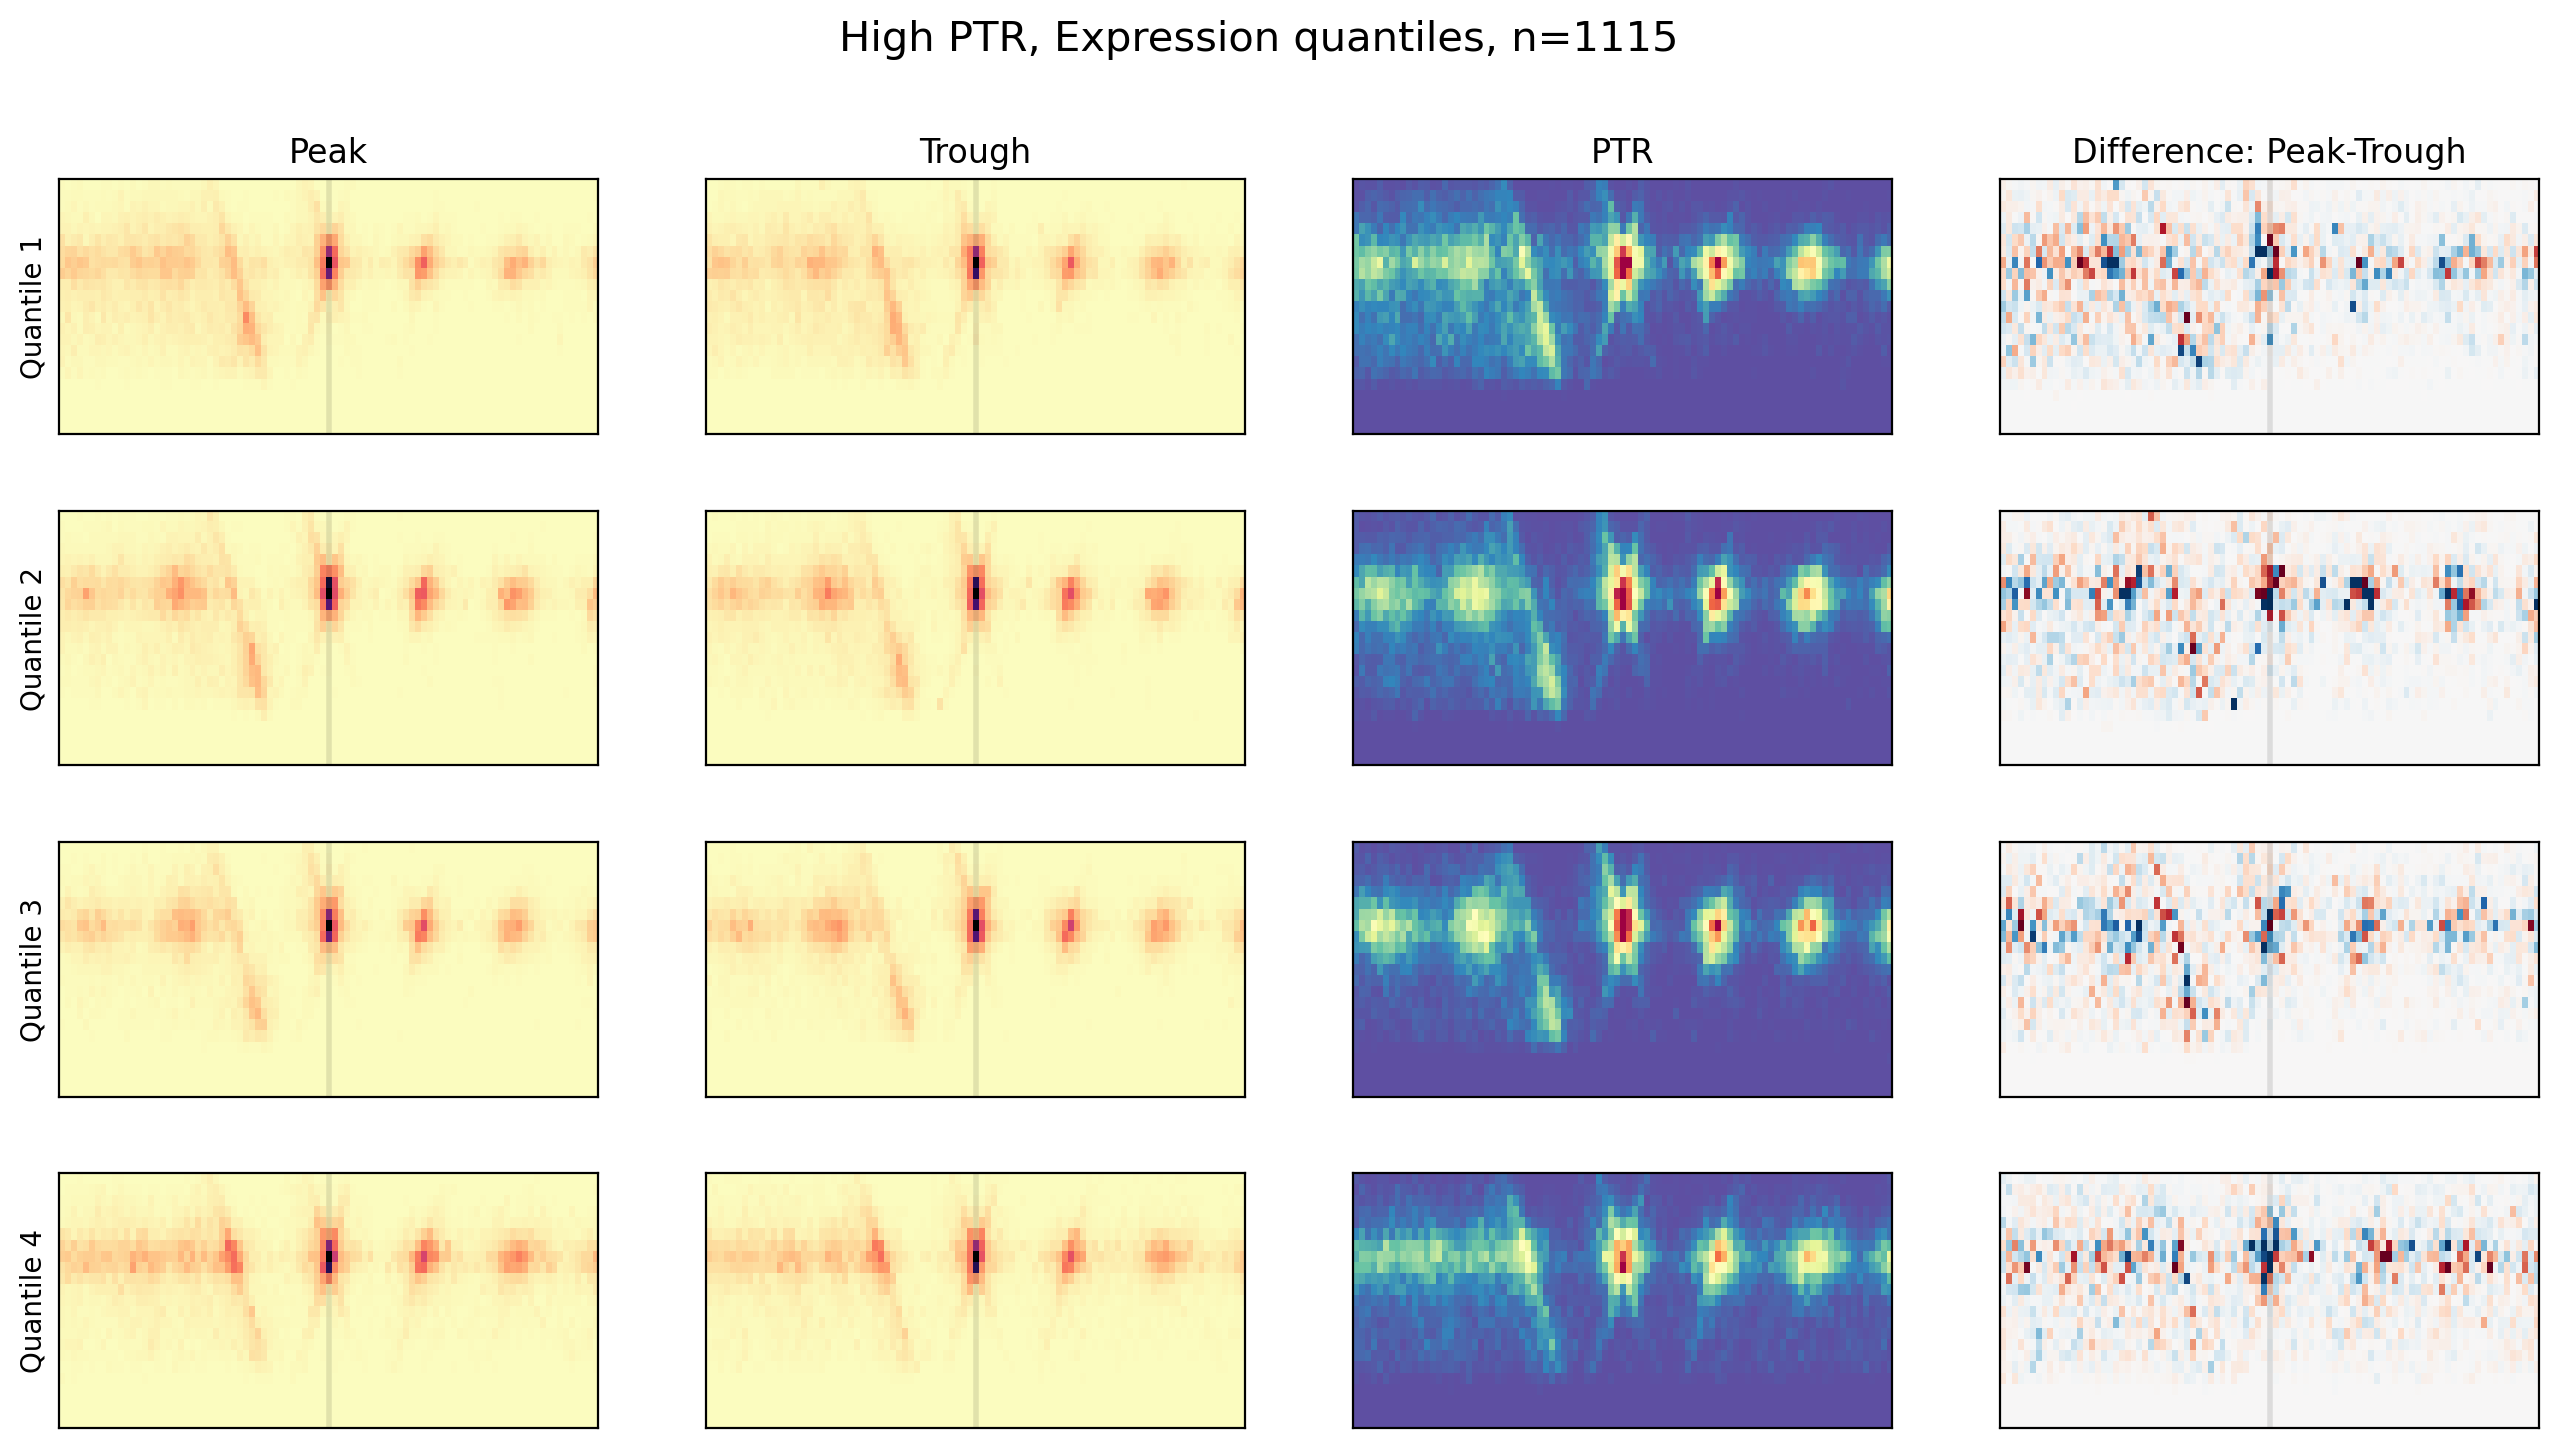

In [536]:
plot_partition_set(hi_ptrs_partition_img_sets, f"High PTR, Expression quantiles, n={len(hi_ptrs_df)}")
save_figure_for_paper("output/figures/Expression_Chromatin/High_PTR_Quantiles_of_Expression.png")